In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp
from sklearn.metrics import roc_curve
import shap



c:\Users\ohrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
df = pd.read_csv('../data/raw/cs-training.csv')
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [38]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [39]:
print(df.describe())

          Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
count  150000.000000     150000.000000                         150000.000000   
mean    75000.500000          0.066840                              6.048438   
std     43301.414527          0.249746                            249.755371   
min         1.000000          0.000000                              0.000000   
25%     37500.750000          0.000000                              0.029867   
50%     75000.500000          0.000000                              0.154181   
75%    112500.250000          0.000000                              0.559046   
max    150000.000000          1.000000                          50708.000000   

                 age  NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  \
count  150000.000000                         150000.000000  150000.000000   
mean       52.295207                              0.421033     353.005076   
std        14.771866                            

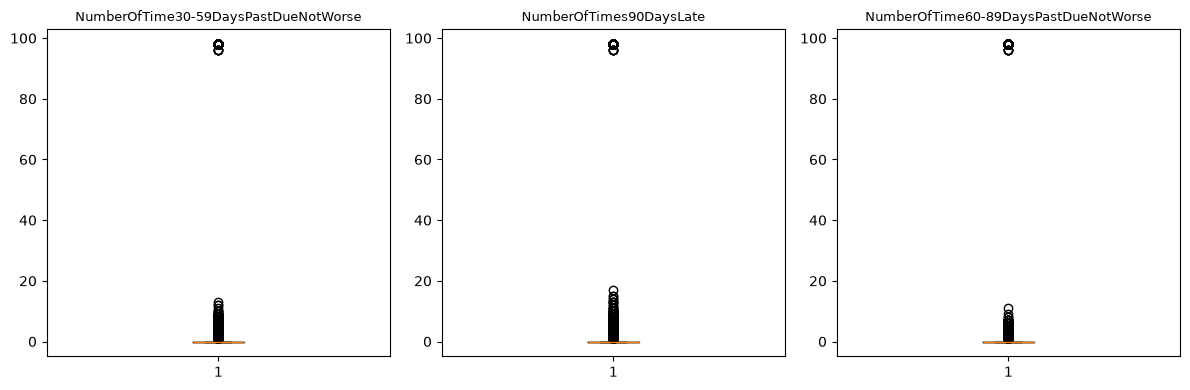

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64



In [40]:
past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, past_due_cols):
    ax.boxplot(df[col])
    ax.set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

for col in past_due_cols:
    print(col)
    print(df[col].value_counts().sort_index())
    print()

In [41]:
print('RevolvingUtilizationOfUnsecuredLines')
for q in [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9999, 1.0]:
    print(f"{q:>7.4f}: {df['RevolvingUtilizationOfUnsecuredLines'].quantile(q):.3f}")


print('DebtRatio')
for q in [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9999, 1.0]:
    print(f"{q:>7.4f}: {df['DebtRatio'].quantile(q):.3f}")


print('MonthlyIncome')
bins = [0, 1, 2, 5, 10, 50, 100, 1000, float('inf')]
bucketed = pd.cut(df['DebtRatio'], bins=bins)
print(df.groupby(bucketed, observed=True)['MonthlyIncome'].apply(lambda s: s.isnull().mean()))
print()
print(df.groupby(bucketed, observed=True).size())

RevolvingUtilizationOfUnsecuredLines
 0.9000: 0.981
 0.9500: 1.000
 0.9700: 1.000
 0.9800: 1.006
 0.9900: 1.093
 0.9950: 1.366
 0.9990: 1571.006
 0.9999: 10151.006
 1.0000: 50708.000
DebtRatio
 0.9000: 1267.000
 0.9500: 2449.000
 0.9700: 3225.000
 0.9800: 3839.000
 0.9900: 4979.040
 0.9950: 6186.010
 0.9990: 10613.074
 0.9999: 40362.002
 1.0000: 329664.000
MonthlyIncome
DebtRatio
(0.0, 1.0]         0.001851
(1.0, 2.0]         0.039101
(2.0, 5.0]         0.321658
(5.0, 10.0]        0.680104
(10.0, 50.0]       0.894665
(50.0, 100.0]      0.929858
(100.0, 1000.0]    0.908253
(1000.0, inf]      0.940800
Name: MonthlyIncome, dtype: float64

DebtRatio
(0.0, 1.0]         110750
(1.0, 2.0]           4092
(2.0, 5.0]           1399
(5.0, 10.0]           769
(10.0, 50.0]         2943
(50.0, 100.0]        1554
(100.0, 1000.0]      7488
(1000.0, inf]       16892
dtype: int64


In [42]:
df.drop(columns = ['Unnamed: 0'], inplace = True)
df['income_was_missing'] = df['MonthlyIncome'].isnull().astype(int)

In [43]:
X = df.drop(columns = ['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print(y_train.value_counts(normalize = True))

X_train: (120000, 11)
X_test: (30000, 11)
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


In [44]:
age_median   = X_train['age'].replace(0, pd.NA).median()
income_median = X_train['MonthlyIncome'].median()
dependents_median = X_train['NumberOfDependents'].median()
revol_cap = X_train['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
debt_cap  = X_train['DebtRatio'].quantile(0.99)


past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in past_due_cols:
    X_train[col] = X_train[col].replace([96, 98], 0)
    X_test[col] = X_test[col].replace([96, 98], 0)


for X in (X_train, X_test):
    X['age'] = X['age'].replace(0, age_median)
    X['MonthlyIncome'] = X['MonthlyIncome'].fillna(income_median)
    X['NumberOfDependents'] = X['NumberOfDependents'].fillna(dependents_median)
    X['RevolvingUtilizationOfUnsecuredLines'] = X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=revol_cap)
    X['DebtRatio'] = X['DebtRatio'].clip(upper=debt_cap)


In [45]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
income_was_missing                      0
dtype: int64
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
income_was_missing                      0
dtype: int64


In [46]:
# Logistic Regression model
lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000)
)
lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',..., 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents', 'income_was_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [47]:
# XGBoost model
scale = (y_train==0).sum() / (y_train==1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [48]:
def evaluate_model(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)

    auc = roc_auc_score(y_test, y_prob)
    ks_stat, _ = ks_2samp(y_prob[y_test==1], y_prob[y_test==0])

    print(f"Model: {name}")
    print(f"AUC: {auc:.4f}")
    print(f"KS Statistic: {ks_stat:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

evaluate_model(lr, X_test, y_test, "Logistic Regression")
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

Model: Logistic Regression
AUC: 0.8588
KS Statistic: 0.5595
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.21      0.76      0.33      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000



Model: XGBoost
AUC: 0.8678
KS Statistic: 0.5790
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.21      0.78      0.34      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.79      0.84     30000





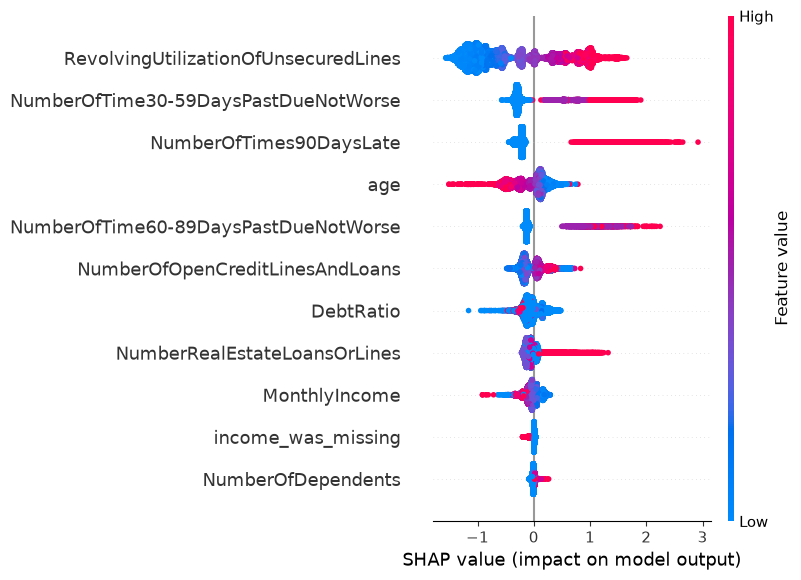

In [49]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

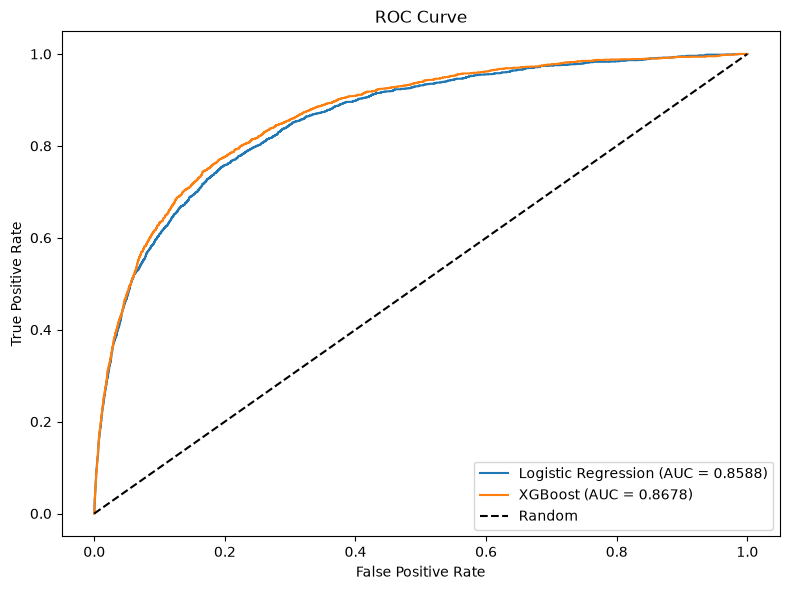

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, name in [(lr, 'Logistic Regression'), (xgb_model, 'XGBoost')]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()